<a href="https://colab.research.google.com/github/MauricioTurdo/Aprendizaje_Automatico/blob/main/Clase%204/Actividad_2_Regresion_Logistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Actividad 2 Regresion Logistica

## Importación de Librería y Carga del Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression

df = pd.read_csv('/content/usuarios_win_mac_lin (1).csv')
df.head()


,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


## Exploración y Análisis Descriptivo EDA

In [8]:
print (df.info ())
print (df.describe())
print(df['clase'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   duracion  170 non-null    float64
 1   paginas   170 non-null    int64  
 2   acciones  170 non-null    int64  
 3   valor     170 non-null    int64  
 4   clase     170 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 6.8 KB
None
         duracion     paginas    acciones       valor       clase
count  170.000000  170.000000  170.000000  170.000000  170.000000
mean   111.075729    2.041176    8.723529   32.676471    0.752941
std    202.453200    1.500911    9.136054   44.751993    0.841327
min      1.000000    1.000000    1.000000    1.000000    0.000000
25%     11.000000    1.000000    3.000000    8.000000    0.000000
50%     13.000000    2.000000    6.000000   20.000000    0.000000
75%    108.000000    2.000000   10.000000   36.000000    2.000000
max    898.000000    9.000000   63.00000

## Separación de variables (Features y Target)

In [9]:
# Variables independientes / características (X)
X = df[['duracion', 'paginas', 'acciones', 'valor']]
# Variable dependiente / objetivo (y)
y = df['clase']

## División en conjunto de Entrenamiento

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Datos de entrenamiento: {len(X_train)} filas")
print(f"Datos de evaluación: {len(X_test)} filas")

Datos de entrenamiento: 136 filas
Datos de evaluación: 34 filas


## Entrenamiento del modelo de Regresión Logística

In [11]:
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

## Predicciones

In [12]:

y_pred = modelo.predict(X_test)

## Evaluación del Modelo

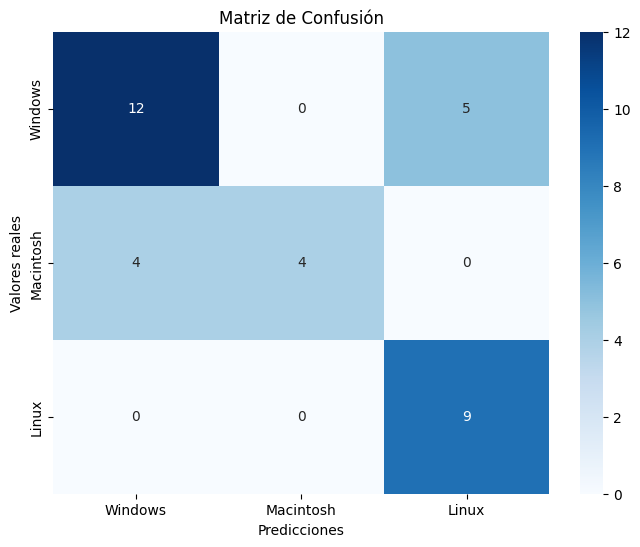

Matriz de confusión:
[[12  0  5]
 [ 4  4  0]
 [ 0  0  9]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.75      0.71      0.73        17
           1       1.00      0.50      0.67         8
           2       0.64      1.00      0.78         9

    accuracy                           0.74        34
   macro avg       0.80      0.74      0.73        34
weighted avg       0.78      0.74      0.73        34



In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Windows', 'Macintosh', 'Linux'],
            yticklabels=['Windows', 'Macintosh', 'Linux'])

plt.title('Matriz de Confusión')
plt.xlabel('Predicciones')
plt.ylabel('Valores reales')
plt.show()

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

## Analisis del Modelo

Para este ejercicio, se utilizó un modelo de regresión logística multinomial.

**Objetivo**: predecir qué sistema operativo utiliza un usuario (0 – Windows, 1 – Macintosh, 2 – Linux) según cuatro variables de comportamiento web: duración, páginas vistas, acciones y valor de las acciones.

**Interpretación:**

Según la matriz de confusión:

Windows (Clase 0): 12 bien clasificados y 5 errores (confundidos como Linux).

Macintosh (Clase 1): 4 bien clasificados y 4 errores (confundidos como Windows).

Linux (Clase 2): 9 de 9 bien clasificados. Perfecto.

El modelo clasifica de buena forma los usuarios de Linux, tiene un desempeño aceptable con Windows y presenta dificultades para identificar a los usuarios de Macintosh (confundiendo la mitad de ellos con Windows).
Reporte de clasificación:

Accuracy = 0.74 -> El modelo acierta el 74% de los casos globales de prueba.

Windows (0) -> Precisión: 0.75, Recall: 0.71 (Detecta adecuadamente a la mayoría de los usuarios de Windows, pero confunde un 29% con Linux).

Macintosh (1) -> Precisión: 1.00, Recall: 0.50 (Cuando dice que un usuario es Mac, acierta el 100% de las veces, pero solo logra detectar al 50% de los Mac reales, clasificando al resto como Windows).

Linux (2) -> Precisión: 0.64, Recall: 1.00 (Detecta al 100% de los usuarios de Linux reales, aunque incluye por error a algunos usuarios de Windows en este grupo).
